# **Notebook 05: Final Domain-Shift Evaluation and System Analysis**

**Description:** This notebook evaluates the frozen Luna v2 policy on held-out Natural Questions and TechQA, compares it with paired static baselines, quantifies uncertainty and feature shift, and exports a blind answer-review sheet without modifying upstream experiment artifacts.

**Main Questions This Notebook Should Answer:**

- How does the frozen source-domain policy perform under technical domain shift?
- How do answer accuracy, task success, coverage, abstention, cost, and retrieval time differ by strategy?
- Are adaptive-versus-static differences supported by paired group-bootstrap intervals?
- What human review and latency evidence remain necessary before deployment?

---

# **Part 1: Configuration and Frozen Artifact Loading**

### **Environment Setup**


In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                 if (p / 'src/adaptive_rag').is_dir() and (p / 'config').is_dir())
sys.path.insert(0, str(REPO_ROOT / 'src'))
ROOT = Path(os.environ.get('ADAPTIVE_RAG_PROJECT_ROOT', REPO_ROOT)).resolve()
from adaptive_rag.luna_v2.common import load_config, load_table, read_json, save_table
cfg = load_config(ROOT)

### **Figure Export Helper**


In [2]:
FIGURES = cfg['paths']['artifacts'] / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 24)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False, 'axes.spines.right': False})
print('Run:', cfg['version'], '| model:', cfg['generation']['model'])
print('Outputs:', cfg['paths']['artifacts'].relative_to(ROOT))

Run: luna-v2 | model: gpt-5.6-luna
Outputs: artifacts\luna_v2


### **Load Frozen Policy and Prior Artifacts**

Report availability exclusions, verify signatures, exclude policy-development rows, and replay every strategy on the same paired held-out examples.

In [3]:
from adaptive_rag.luna_v2.policy import load_policy
from adaptive_rag.luna_v2.report import final_evaluation
from adaptive_rag.luna_v2.evaluation import paired_complete_cases
cohort = load_table(cfg, 'cohort', processed=True)
rankings = load_table(cfg, 'rankings')
evaluated_all = load_table(cfg, 'evaluated_generations')
evaluated, exclusions = paired_complete_cases(evaluated_all)
display(exclusions)
bundle = load_policy(cfg)
replay, summary, intervals, drift = final_evaluation(cfg, bundle, cohort, rankings, evaluated)
display(summary.round(4))

,example_id,domain,split,unavailable_conditions,unavailable_statuses
0,techqa_DEV_Q037,techqa,techqa_test,hybrid_rrf_reranked,failed
1,techqa_DEV_Q104,techqa,techqa_test,direct,failed
2,techqa_DEV_Q114,techqa,techqa_test,"direct,hybrid_rrf,hybrid_rrf_reranked",failed
3,techqa_DEV_Q137,techqa,techqa_test,direct,failed
4,techqa_DEV_Q157,techqa,techqa_test,direct,failed
5,techqa_DEV_Q234,techqa,techqa_test,direct,failed
6,techqa_DEV_Q270,techqa,techqa_test,"hybrid_rrf,hybrid_rrf_reranked",failed
7,techqa_TRAIN_Q111,techqa,techqa_test,direct,failed
8,techqa_TRAIN_Q192,techqa,techqa_test,direct,failed
9,techqa_TRAIN_Q200,techqa,techqa_test,direct,failed


,domain,system,stratum,examples,answerable_examples,answer_accuracy,task_success,coverage,selective_answer_accuracy,unnecessary_abstention_rate,mean_utility,mean_estimated_batch_usd,mean_retrieval_ms
0,natural_questions,DIRECT,all,74,74,0.2838,0.2838,0.9595,0.2958,0.0405,0.1149,0.0000,0.0000
1,natural_questions,DIRECT,answerable,74,74,0.2838,0.2838,0.9595,0.2958,0.0405,0.1149,0.0000,0.0000
2,natural_questions,ESCALATE,all,74,74,0.3919,0.3919,0.7568,0.5179,0.2432,0.3007,0.0002,521.4019
3,natural_questions,ESCALATE,answerable,74,74,0.3919,0.3919,0.7568,0.5179,0.2432,0.3007,0.0002,521.4019
4,natural_questions,RETRIEVE,all,74,74,0.3919,0.3919,0.7703,0.5088,0.2297,0.2973,0.0002,113.5794
5,natural_questions,RETRIEVE,answerable,74,74,0.3919,0.3919,0.7703,0.5088,0.2297,0.2973,0.0002,113.5794
6,natural_questions,adaptive,all,74,74,0.3919,0.3919,0.7703,0.5088,0.2297,0.2973,0.0002,113.5794
7,natural_questions,adaptive,answerable,74,74,0.3919,0.3919,0.7703,0.5088,0.2297,0.2973,0.0002,113.5794
8,techqa,DIRECT,all,894,602,0.0050,0.0291,0.9105,0.0037,0.0947,-0.1977,0.0001,0.0000
9,techqa,DIRECT,answerable,602,602,0.0050,0.0050,0.9053,0.0055,0.0947,-0.2201,0.0001,0.0000


---

# **Part 2: Primary Strategy Comparison**

### **Quality, Coverage, and Paired Uncertainty**

Compare answer accuracy and actual issued-answer coverage, then inspect group-bootstrap intervals.

,domain,baseline,metric,examples,clusters,adaptive_minus_baseline,ci_low,ci_high,note
0,natural_questions,DIRECT,task_success,74,74,0.10811,0.00000,0.22973,Fixed-model uncertainty over sampled query/pag...
1,natural_questions,DIRECT,task_utility,74,74,0.18243,0.05068,0.32095,Fixed-model uncertainty over sampled query/pag...
2,natural_questions,DIRECT,estimated_cost_usd,74,74,0.00019,0.00019,0.00020,Fixed-model uncertainty over sampled query/pag...
3,natural_questions,RETRIEVE,task_success,74,74,0.00000,0.00000,0.00000,Fixed-model uncertainty over sampled query/pag...
4,natural_questions,RETRIEVE,task_utility,74,74,0.00000,0.00000,0.00000,Fixed-model uncertainty over sampled query/pag...
5,natural_questions,RETRIEVE,estimated_cost_usd,74,74,0.00000,0.00000,0.00000,Fixed-model uncertainty over sampled query/pag...
6,natural_questions,ESCALATE,task_success,74,74,0.00000,-0.08108,0.08108,Fixed-model uncertainty over sampled query/pag...
7,natural_questions,ESCALATE,task_utility,74,74,-0.00338,-0.08446,0.08108,Fixed-model uncertainty over sampled query/pag...
8,natural_questions,ESCALATE,estimated_cost_usd,74,74,0.00001,0.00000,0.00001,Fixed-model uncertainty over sampled query/pag...
9,techqa,DIRECT,task_success,894,894,0.11409,0.09060,0.13870,Fixed-model uncertainty over sampled query/pag...


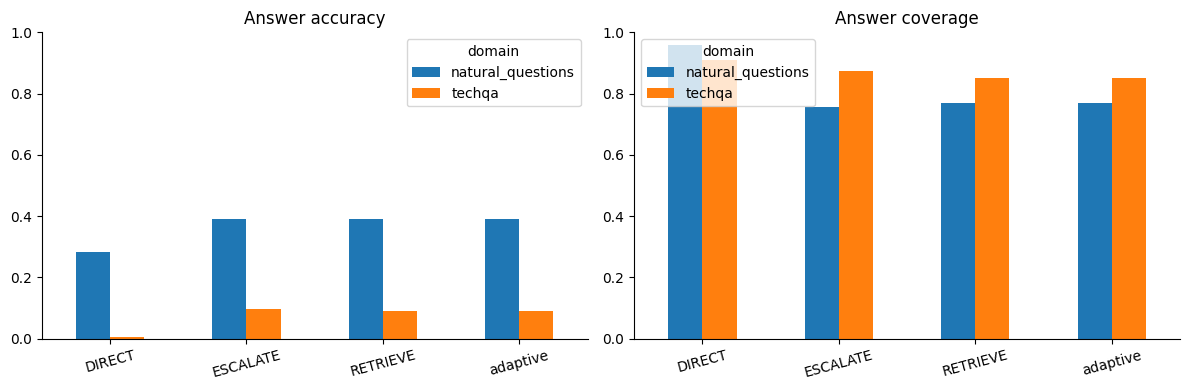

In [4]:
display(intervals.round(5))
all_rows = summary[summary.stratum.eq('all')]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, label in zip(axes, ['answer_accuracy', 'coverage'], ['Answer accuracy', 'Answer coverage']):
    all_rows.pivot(index='system', columns='domain', values=metric).plot.bar(ax=ax)
    ax.set(title=label, xlabel='', ylim=(0, 1))
    ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(FIGURES / '05_quality_and_coverage.png', dpi=160)
plt.show()

### **Results Interpretation**

The adaptive policy exactly matches Hybrid RRF because it selects RETRIEVE for every held-out example. On NQ, it improves task success over direct generation by 10.8 percentage points, but the 95% paired-bootstrap interval spans 0.0 to 23.0 points because only 74 examples are available. On TechQA, the gain over direct is 11.4 points with a tighter 9.1-to-13.9-point interval.

The adaptive-versus-reranked differences include zero in both domains, so the experiment supports retrieval over direct generation but does not establish an adaptive or reranking advantage.

---

# **Part 3: Latency, Cost, and Routing Analysis**

### **Resource Accounting and Routing Matrix**

Report estimated selected-condition Batch cost separately from the cost of all experimental calls.

In [5]:
display(all_rows[['domain', 'system', 'examples', 'mean_estimated_batch_usd', 'mean_retrieval_ms']].round(6))
assert replay.generation_latency_ms.isna().all()
display(replay.groupby(['domain', 'system', 'action']).size().rename('queries').reset_index())
from adaptive_rag.luna_v2.generation import generation_status
spend_status = generation_status(cfg)
print('All-attempt conservative spending reservation: $', round(spend_status['reserved_usd_all_attempts'], 4))
print('Recorded usage estimate, all successful experimental conditions: $', round(evaluated.estimated_cost_usd.sum(), 4))

,domain,system,examples,mean_estimated_batch_usd,mean_retrieval_ms
0,natural_questions,DIRECT,74,0.000023,0.000000
2,natural_questions,ESCALATE,74,0.000209,521.401946
4,natural_questions,RETRIEVE,74,0.000214,113.579365
6,natural_questions,adaptive,74,0.000214,113.579365
8,techqa,DIRECT,894,0.000071,0.000000
11,techqa,ESCALATE,894,0.000222,407.025693
14,techqa,RETRIEVE,894,0.000222,314.730739
17,techqa,adaptive,894,0.000222,314.730739


,domain,system,action,queries
0,natural_questions,DIRECT,DIRECT,74
1,natural_questions,ESCALATE,ESCALATE,74
2,natural_questions,RETRIEVE,RETRIEVE,74
3,natural_questions,adaptive,RETRIEVE,74
4,techqa,DIRECT,DIRECT,894
5,techqa,ESCALATE,ESCALATE,894
6,techqa,RETRIEVE,RETRIEVE,894
7,techqa,adaptive,RETRIEVE,894


All-attempt conservative spending reservation: $ 3.3422
Recorded usage estimate, all successful experimental conditions: $ 0.6253


### **Results Interpretation**

All 968 adaptive decisions use RETRIEVE, so the policy creates no route-dependent savings. Mean retrieval time is 113.6 ms on NQ and 314.7 ms on TechQA, compared with 521.4 and 407.0 ms for reranking. Mean selected-call Batch cost is approximately USD 0.000214 on NQ and USD 0.000222 on TechQA, versus USD 0.000023 and USD 0.000071 for direct generation. These figures exclude synchronous generation latency, which Batch does not provide.

---

# **Part 4: Domain Shift and Representative Failures**

### **Feature Shift and End-to-End Cases**

Inspect the largest standardized feature shifts and representative answerable failures.

In [6]:
display(drift.sort_values('standardized_mean_shift', key=lambda s: s.abs(), ascending=False).head(20).round(3))
adaptive = replay[replay.system.eq('adaptive')]
cases = adaptive.merge(cohort[['example_id', 'question', 'answer']], on='example_id')
display(cases[cases.answerable & ~cases.answer_correct]
        [['domain', 'question', 'answer', 'action', 'generated_answer']].head(12))

,domain,feature,train_mean,test_mean,standardized_mean_shift
15,techqa,question_token_length,9.167,58.663,29.390
14,techqa,question_char_length,47.738,355.973,27.768
18,techqa,code_symbol_density,0.000,0.030,25.302
16,techqa,query_lexical_diversity,0.968,0.638,-5.847
20,techqa,technical_term_density,0.001,0.036,3.422
7,natural_questions,nq_centroid_similarity,0.148,0.222,1.573
19,techqa,numeric_token_density,0.012,0.070,1.438
8,natural_questions,nearest_train_similarity,0.201,0.355,1.333
21,techqa,nq_centroid_similarity,0.148,0.201,1.118
27,techqa,hybrid_entropy,2.283,2.291,0.450


,domain,question,answer,action,generated_answer
2,natural_questions,by what name did the portuguese call the regio...,Bombay,RETRIEVE,Bombaim.
3,natural_questions,who plays bays grandma on switched at birth,Ivonne Coll,RETRIEVE,INSUFFICIENT_EVIDENCE
4,natural_questions,who is nominated for nobel peace prize 2016,Juan Manuel Santos,RETRIEVE,Juan Manuel Santos was nominated and awarded t...
6,natural_questions,how many goals has lampard scored for england,29,RETRIEVE,INSUFFICIENT_EVIDENCE
11,natural_questions,what episode in season 3 do jim and pam get to...,"the season finale , `` The Job , ''",RETRIEVE,"Season 3, episode 25, “The Job.”"
12,natural_questions,distance from las vegas to red wood forest,15 miles,RETRIEVE,INSUFFICIENT_EVIDENCE
14,natural_questions,who does ariel winter voice on phineas and ferb,Gretchen,RETRIEVE,Sofia the First.
15,natural_questions,what was the purpose of the protective tariffs...,protecting U.S. manufactured items from overse...,RETRIEVE,To protect U.S. manufacturers from European co...
16,natural_questions,when was last time england was in semi final o...,2018,RETRIEVE,1990 — England’s most recent FIFA World Cup se...
19,natural_questions,what was the drug on 21 jump street,HFS,RETRIEVE,INSUFFICIENT_EVIDENCE


### **Results Interpretation**

TechQA differs sharply from NQ training: mean question-token length shifts by 29.4 training standard deviations, character length by 27.8, code-symbol density by 25.3, and lexical diversity by -5.85. NQ test shifts are much smaller, led by centroid similarity at 1.57 standard deviations. The extreme target-domain changes help explain why a policy selected on short NQ questions does not produce useful dynamic routing on technical questions.

---

# **Part 5: Human Audit and Release Evidence**

### **Final Report Manifest**

Review the fixed policy signature, cohort counts, limitations, and research-only deployment status.

In [7]:
display(read_json(cfg['paths']['artifacts'] / 'final_report_manifest.json'))

{'policy_signature': '9b1af82479bcdc371a06911b5b6f44f250cbc1b6285ee166025e5a87fd502f76',
 'heldout_examples': 968,
 'domain_counts': {'techqa': 894, 'natural_questions': 74},
 'deployment_status': 'research_only_pending_human_quality_review_and_online_latency_validation',
 'limitations': ['TechQA lexical answer accuracy is a proxy; complete the blind review.',
  'Batch generation latency is unavailable; retrieval time is not end-to-end latency.',
  'Thresholds and model selection used only NQ validation, with small source samples.',
  'Budget/cost figures are estimates, not an invoice or provider-enforced hard cap.',
  'No calibrated-confidence claim; rare classes may require constant stage rules.',
  'NQ negatives and long-only records are excluded from primary generation.',
  'The frozen policy remains comparison-only; static Hybrid RRF is the strongest baseline.']}

### **Results Interpretation**

The final status remains research-only. TechQA mean utility is still negative (-0.055) under the best selected route, and its automatic long-answer accuracy is only a lexical proxy. The exported 180-row blind audit must be completed before making answer-quality claims. A separate synchronous benchmark is also required because the reported timings cover retrieval only, not end-to-end response latency.

---

# **Part 6: Conclusion**

This notebook evaluated the frozen policy on 968 paired held-out examples: 74 NQ and 894 TechQA, after 14 TechQA examples were excluded for unavailable responses. Because the policy selected RETRIEVE for every example, its results exactly match Hybrid RRF and do not demonstrate dynamic routing.

On NQ, answer accuracy and task success were 39.2% versus 28.4% for direct generation (+10.8 percentage points; 95% paired-bootstrap CI 0.0 to 23.0), and matched reranking while using 113.6 ms rather than 521.4 ms mean retrieval time. On TechQA, answer accuracy was 9.1% versus 0.5% direct and 9.6% reranked; task success was 14.3% versus 2.9% direct (+11.4 points; 95% CI 9.1 to 13.9) and 14.1% reranked.

TechQA mean utility remained negative at -0.055, and very large shifts in question length and code-symbol density show weak source-to-target transfer. The 180-row blind audit and a separate synchronous latency test remain required before deployment.

---